In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/andrealuigipala-del/ProfessionAI_projects/refs/heads/main/housing.csv")

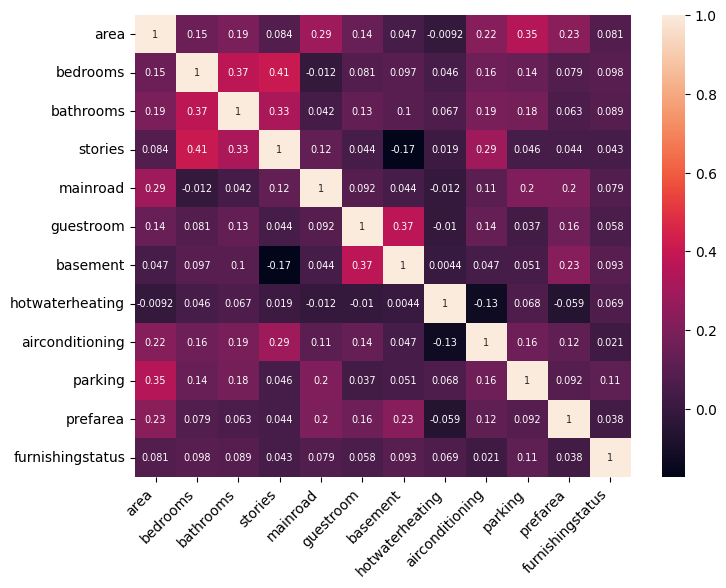

In [ ]:
# importo i dati ---
df = pd.DataFrame(data)
# verifico presenza di NaN ---
df.isna().sum() # --> nessuna presenza di NaN
# ricavo le features ---
X = df.drop(columns=["price"])
# ricavo il target ---
y = df["price"]



# visualizzo matrice di correlazione per rilevare se presente ridondanza / indipendenza tra le variabili ---
corr = X.corr()
columns = X.columns
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot = True,
           xticklabels=columns,
           yticklabels=columns,
           annot_kws={'size':7}, #modifico grandezza test o font dei numeri
           )
plt.xticks(rotation=45, ha='right')  # ruota etichette x
plt.yticks(rotation=0)
plt.show() # --> nessuna correlazione individuata perché i valori si attestano quasi tutti < 0.45

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 0)

In [ ]:
# standardizzo i dati ---
x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)


In [ ]:
# provo regressione lineare pura ---
for d in range(0,7):

    poly = PolynomialFeatures(d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)

    y_pred_train = lr.predict(X_train_poly)
    mse_train = mean_squared_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    y_pred_test = lr.predict(X_test_poly)
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"\nDegree: {d}\n",
          f"MSE Train: {mse_train:.2f}\n",
          f"R2 Train: {r2_train:.2f}\n",
          f"MSE Test: {mse_test:.2f}\n",
          f"R2 Test: {r2_test:.2f}\n")

  # outcome: mi rendo conto che il grado migliore è il primo, ma l'R2 non è soddisfacente --> attuo la regolarizzazione


Degree: 0
 MSE Train: 3502169709236.73
 R2 Train: 0.00
 MSE Test: 3468795874195.35
 R2 Test: -0.00


Degree: 1
 MSE Train: 1204930725280.43
 R2 Train: 0.66
 MSE Test: 961887082256.53
 R2 Test: 0.72


Degree: 2
 MSE Train: 801017365922.15
 R2 Train: 0.77
 MSE Test: 1823534551571.51
 R2 Test: 0.47


Degree: 3
 MSE Train: 132077592460.60
 R2 Train: 0.96
 MSE Test: 170235239751850.78
 R2 Test: -48.08


Degree: 4
 MSE Train: 18459476393.40
 R2 Train: 0.99
 MSE Test: 43849278850240752.00
 R2 Test: -12640.14


Degree: 5
 MSE Train: 14892082257.01
 R2 Train: 1.00
 MSE Test: 7168927138830779392.00
 R2 Test: -2066702.11


Degree: 6
 MSE Train: 11214447620.48
 R2 Train: 1.00
 MSE Test: 4958447619493925226545152.00
 R2 Test: -1429452265401.92



In [ ]:
# salvo il risultato MSE del miglior modello attualmente trovato (polinomiale grado 1) in MSE_linear_degree1

poly = PolynomialFeatures(1)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_linear_regression_1 = LinearRegression()
model_linear_regression_1.fit(X_train_poly, y_train)

y_pred_test = model_linear_regression_1.predict(X_test_poly)
mse_test = mean_squared_error(y_test, y_pred_test)

MSE_linear_degree1 = mse_test

In [ ]:
# definisco una funzione per analizzare il risultato di ciascuna regolarizzazione
def evaluate_model(model,dataset):

    X, y = dataset

    y_pred = model.predict(X)

    print(f"MSE: {mean_squared_error(y,y_pred):.3f}")
    print(f"R2: {r2_score(y,y_pred):.3f}")
    return mean_squared_error(y,y_pred)

In [ ]:
# provo con la regolarizzazione Ridge
alphas = [0.1, 1, 10, 100]
model_ridge = RidgeCV(alphas) # uso RidgeCV invece che Ridge per avere un alpha ottimizzato così da ridurre i tentativi con diversi alpha. Stessa cosa con LassoCV ed ElasticNetCV
model_ridge.fit(X_train,y_train)
evaluate_model(model_ridge, (X_train,y_train))
MSE_Ridge = evaluate_model(model_ridge, (X_test,y_test))
alpha_Ridge = model_ridge.alpha_

MSE: 1205382268601.543
R2: 0.656
MSE: 958023427085.304
R2: 0.724


In [ ]:
# provo con la regolarizzazione Lasso
model_lasso = LassoCV(alphas=None)
model_lasso.fit(X_train,y_train)
evaluate_model(model_lasso, (X_train,y_train))
MSE_Lasso = evaluate_model(model_lasso, (X_test,y_test))
alpha_Lasso = model_lasso.alpha_

MSE: 1204936158614.164
R2: 0.656
MSE: 961084691962.118
R2: 0.723


In [ ]:
# non avendo ottenuto nessun miglioramento rilevante, provo con elastic-net
from sklearn.linear_model import ElasticNet
model_elastic_net = ElasticNetCV(alphas=[0.01, 0.1, 1], l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=0, max_iter=10000)
model_elastic_net.fit(X_train,y_train)
evaluate_model(model_elastic_net, (X_train, y_train))
MSE_elastic_net = evaluate_model(model_elastic_net, (X_test, y_test))
alpha_ElasticNet = model_elastic_net.alpha_

MSE: 1209681155174.528
R2: 0.655
MSE: 953769680424.376
R2: 0.725


In [ ]:
# Cross validation su dati non standardizzati (cross_val_score)
from sklearn.model_selection import cross_val_score
# Modello Lasso
model_Lasso_cvs = Lasso(alpha_Lasso)
R2_Lasso_cvs = cross_val_score(model_Lasso_cvs, X, y, cv=5, scoring = "r2") # cv --> numero di batch nelle quali voglio dividere il mio dataset
MSE_Lasso_cvs = -cross_val_score(model_Lasso_cvs, X, y, cv=5, scoring = "neg_mean_squared_error").mean() # cv --> numero di batch nelle quali voglio dividere il mio dataset
print(f"Modello Lasso: R2 medio = {R2_Lasso_cvs.mean()}")

Modello Lasso: R2 medio = -9.969938231789255


In [ ]:
# Modello Ridge
model_Ridge_cvs = Ridge(alpha_Ridge)
R2_Ridge_cvs = cross_val_score(model_Ridge_cvs, X, y, cv=5, scoring = "r2") # cv --> numero di batch nelle quali voglio dividere il mio dataset
MSE_Ridge_cvs = -cross_val_score(model_Ridge_cvs, X, y, cv=5, scoring = "neg_mean_squared_error").mean() # cv --> numero di batch nelle quali voglio dividere il mio dataset
print(f"Modello Ridge: R2 medio = {R2_Ridge_cvs.mean()}")

Modello Ridge: R2 medio = -9.712329092536866


In [ ]:
# Cross validation su dati non standardizzati (cross_validate)
from sklearn.model_selection import cross_validate
# Modello Lasso
model_Lasso_cv = Lasso(alpha_Lasso)
cv_result = cross_validate(model_Lasso_cv, X, y, cv=5, scoring="neg_mean_squared_error", return_train_score=True)
print(f"Modello Lasso: \nMSE medio train = {
    cv_result["train_score"].mean()}\nMSE medio test = {
    cv_result["test_score"].mean()}")
MSE_Lasso_cv = -cv_result["test_score"].mean()

Modello Lasso: 
MSE medio train = -1045612076257.3529
MSE medio test = -2164454701327.814


In [ ]:
# Modello Ridge
model_Ridge_cv = Ridge(alpha_Ridge)
cv_result = cross_validate(model_Ridge_cv, X, y, cv=5, scoring="neg_mean_squared_error", return_train_score=True)
print(f"Modello Ridge: \nMSE medio train = {
    cv_result["train_score"].mean()}\nMSE medio test = {
    cv_result["test_score"].mean()}")
MSE_Ridge_cv = -cv_result["test_score"].mean()

Modello Ridge: 
MSE medio train = -1054091329094.4658
MSE medio test = -2214894001194.242


In [ ]:
# Cross validation su dati standardizzati (KFold)
from sklearn.model_selection import KFold
# Con modello Lasso
RANDOM_SEED = 0
kf = KFold(n_splits = 5, shuffle=True, random_state = RANDOM_SEED)

train_score = []
test_score = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y[train_index], y[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.fit_transform(X_test)

    model_Lasso_ss = LassoCV(alphas=None)
    model_Lasso_ss.fit(X_train, y_train)

    MSE_Lasso_train_ss = mean_squared_error(y_train, model_Lasso_ss.predict(X_train))
    MSE_Lasso_test_ss = mean_squared_error(y_test, model_Lasso_ss.predict(X_test))

    train_score.append(MSE_Lasso_train_ss)
    test_score.append(MSE_Lasso_test_ss)

scores = {
    "train_score" : np.array(train_score),
    "test_score" : np.array(test_score)
}

print(f"MSE Lasso con ss sui train = {np.array(train_score).mean()}")
print(f"MSE Lasso con ss sui test = {np.array(test_score).mean()}")

MSE_Lasso_ss = np.array(test_score).mean()


MSE Lasso con ss sui train = 1112649127179.0896
MSE Lasso con ss sui test = 1227205540462.752


In [ ]:
# Con modello Ridge
RANDOM_SEED = 0
kf = KFold(n_splits = 5, shuffle=True, random_state = RANDOM_SEED)

train_score = []
test_score = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y[train_index], y[test_index]

    ss = StandardScaler()
    X_train = ss.fit_transform(X_train)
    X_test = ss.fit_transform(X_test)

    model_Ridge_ss = RidgeCV(alphas)
    model_Ridge_ss.fit(X_train, y_train)

    MSE_Ridge_train_ss = mean_squared_error(y_train, model_Ridge_ss.predict(X_train))
    MSE_Ridge_test_ss = mean_squared_error(y_test, model_Ridge_ss.predict(X_test))

    train_score.append(MSE_Ridge_train_ss)
    test_score.append(MSE_Ridge_test_ss)

scores = {
    "train_score" : np.array(train_score),
    "test_score" : np.array(test_score)
}

print(f"MSE Ridge con ss sui train = {np.array(train_score).mean()}")
print(f"MSE Ridge con ss sui test = {np.array(test_score).mean()}")

MSE_Ridge_ss = np.array(test_score).mean()


MSE Ridge con ss sui train = 1113004652319.9863
MSE Ridge con ss sui test = 1225073027909.352


In [ ]:
# calcolo coefficienti di ciascun modello analizzato ---

coeff_model_linear_regression_1 = np.sum(model_linear_regression_1.coef_ != 0)
coeff_model_ridge = np.sum(model_ridge.coef_ != 0)
coeff_model_lasso = np.sum(model_lasso.coef_ != 0)
coeff_model_elastic_net = np.sum(model_elastic_net.coef_ != 0)
coeff_model_Ridge_ss = np.sum(model_Ridge_ss.coef_ != 0)
coeff_model_Lasso_ss = np.sum(model_Lasso_ss.coef_ != 0)

In [ ]:
nomi_modelli = ["MSE modello polinommiale grado 1",
                "MSE modello Lasso",
                "MSE modello Ridge",
                "MSE modello Elastic-net",
                "MSE cross-validation con Lasso (funzione cvs)",
                "MSE cross-validation con Ridge (funzione cvs)",
                "MSE cross-validation con Lasso (funzione cv)",
                "MSE cross-validation con Ridge (funzione cv)",
                "MSE cross-validation con Lasso (dati standardizzati)",
                "MSE cross-validation con Ridge (dati standardizzati)"]

Coefficienti_modelli = [coeff_model_linear_regression_1,
                        coeff_model_lasso,
                        coeff_model_ridge,
                        "NA",
                        "NA",
                        "NA",
                        "NA",
                        coeff_model_elastic_net,
                        coeff_model_Lasso_ss,
                        coeff_model_Ridge_ss]

mse_values = [MSE_linear_degree1,MSE_Lasso,MSE_Ridge,MSE_elastic_net,MSE_Lasso_cvs,MSE_Ridge_cvs,MSE_Lasso_cv,MSE_Ridge_cv,MSE_Lasso_ss,MSE_Ridge_ss]

tabella = pd.DataFrame({
    "Tipo analisi": nomi_modelli,
    "risultato MSE": mse_values,
    "N° coefficienti modello": Coefficienti_modelli})



In [ ]:
# tabella riassuntiva del MSE calcolato per ciascun modello ed a fronte di Cross-validation analysis, comprensiva di valutazione complessità a partire dal N di coefficienti di ciascun modello ---
tabella

,Tipo analisi,risultato MSE,N° coefficienti modello
0,MSE modello polinommiale grado 1,9.618871e+11,12
1,MSE modello Lasso,9.610847e+11,12
2,MSE modello Ridge,9.580234e+11,12
3,MSE modello Elastic-net,9.537697e+11,NA
4,MSE cross-validation con Lasso (funzione cvs),2.164455e+12,NA
5,MSE cross-validation con Ridge (funzione cvs),2.214894e+12,NA
6,MSE cross-validation con Lasso (funzione cv),2.164455e+12,NA
7,MSE cross-validation con Ridge (funzione cv),2.214894e+12,12
8,MSE cross-validation con Lasso (dati standardi...,1.227206e+12,12
9,MSE cross-validation con Ridge (dati standardi...,1.225073e+12,12


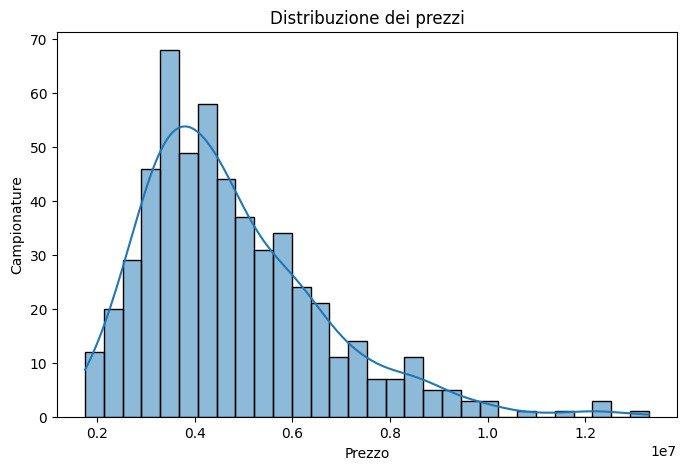

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribuzione dei prezzi")
plt.xlabel("Prezzo")
plt.ylabel("Campionature")
plt.show()

#la distribuzione dei prezzi asimmetrica fa presagire che un modello di regressione lineare può non essere opportuno, se non per un range di prezzi relativamente basso.


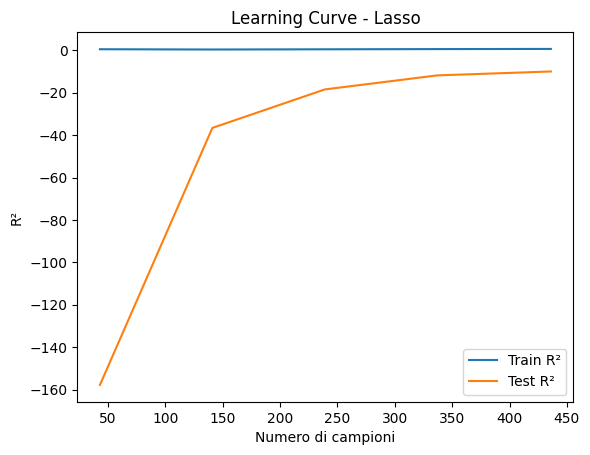

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    Lasso(alpha_Lasso),
    X,
    y,
    cv=5,
    scoring='r2'
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train R²")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test R²")
plt.xlabel("Numero di campioni")
plt.ylabel("R²")
plt.title("Learning Curve - Lasso")
plt.legend()
plt.show()

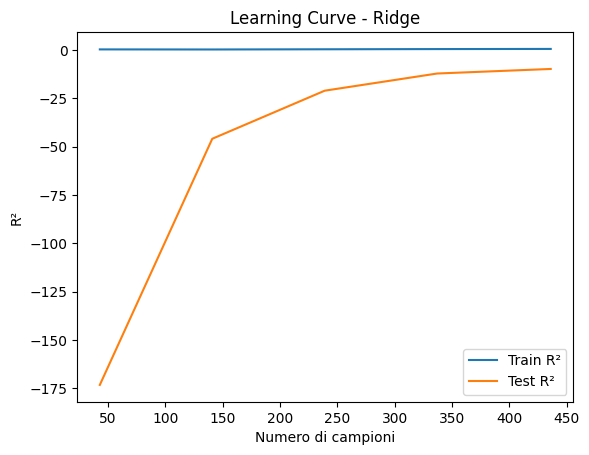

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    Ridge(alpha_Ridge),
    X,
    y,
    cv=5,
    scoring='r2'
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train R²")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test R²")
plt.xlabel("Numero di campioni")
plt.ylabel("R²")
plt.title("Learning Curve - Ridge")
plt.legend()
plt.show()

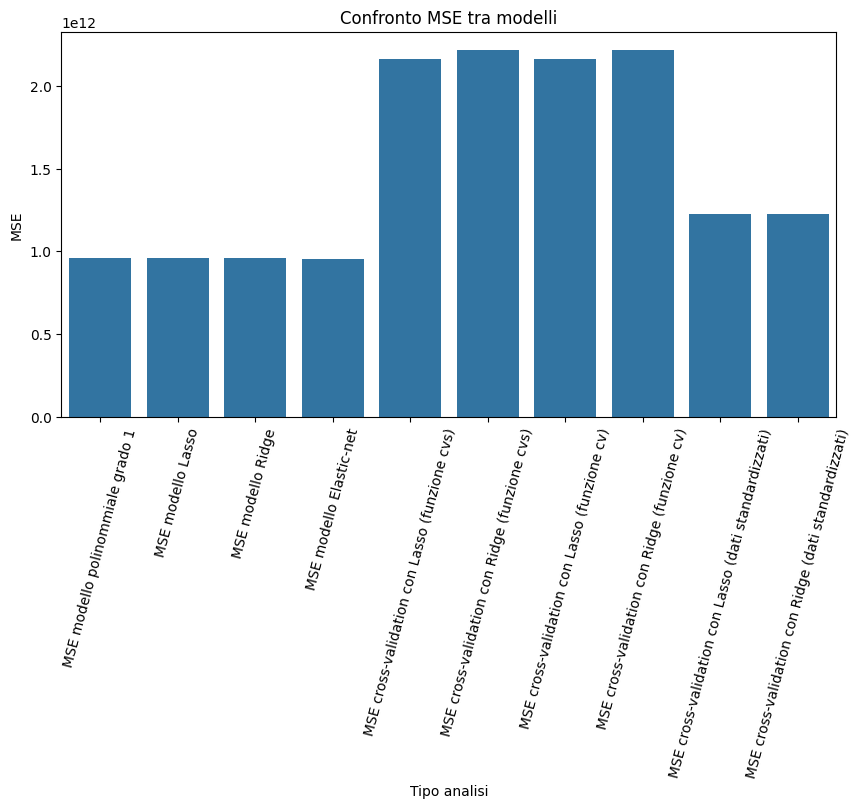

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=tabella['Tipo analisi'], y=tabella['risultato MSE'])
plt.xticks(rotation=75)
plt.ylabel("MSE")
plt.title("Confronto MSE tra modelli")
plt.show()

# il modello più appropriato secondo il MSE (e l'R2) è quello polinomiale di grado 1.

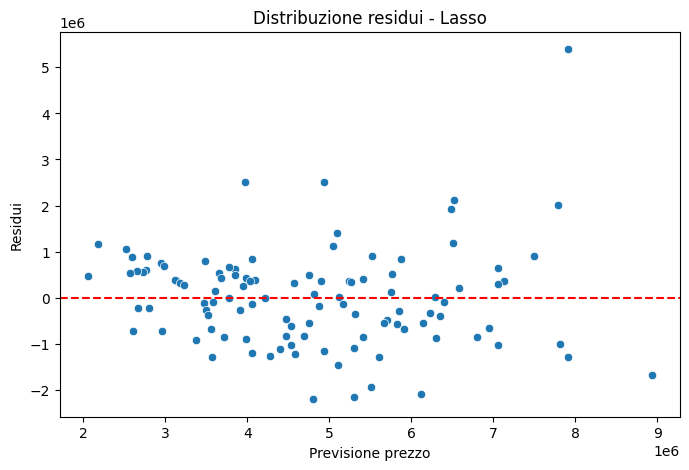

In [ ]:
y_pred = model_lasso.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=np.ravel(y_pred), y=np.ravel(residuals))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Previsione prezzo")
plt.ylabel("Residui")
plt.title("Distribuzione residui - Lasso")
plt.show()



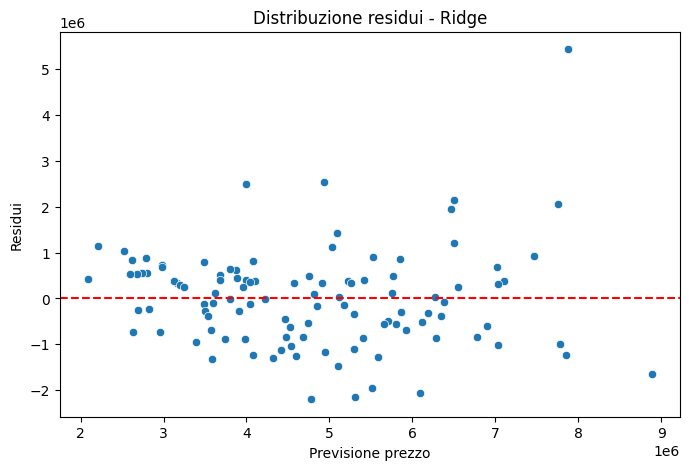

In [ ]:
y_pred = model_ridge.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=np.ravel(y_pred), y=np.ravel(residuals))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Previsione prezzo")
plt.ylabel("Residui")
plt.title("Distribuzione residui - Ridge")
plt.show()

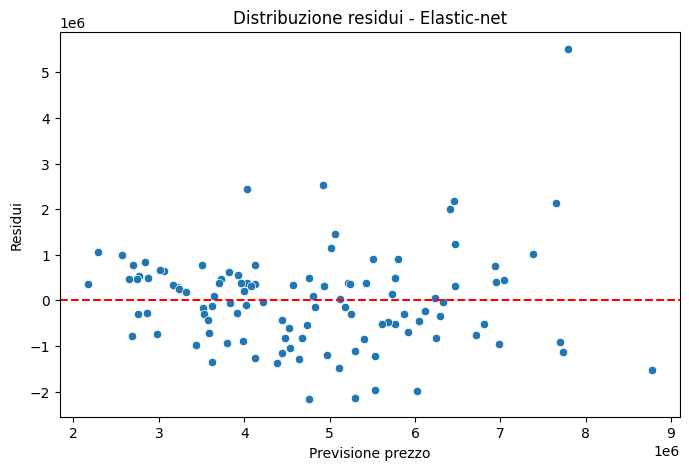

In [ ]:
y_pred = model_elastic_net.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=np.ravel(y_pred), y=np.ravel(residuals))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Previsione prezzo")
plt.ylabel("Residui")
plt.title("Distribuzione residui - Elastic-net")
plt.show()